In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('.venv/20_cmapss_fd001_sample.csv')


In [3]:
# 실습 1. C-MAPSS 데이터 열고 구조 확인
print(df.isna().sum().sum())

# print(df.describe())

# 실습 2. 엔진 단위와 작동 길이 파악
print('엔진 대수:', df['unit_nr'].nunique()) # 엔진 대수: 5
print('엔진별 사이클 기록수:', df['unit_nr'].value_counts().sort_index())
# 엔진별 사이클 기록수: unit_nr
# 엔진별 사이클 기록수: unit_nr
# 1    192
# 2    287
# 3    179
# 4    189
# 5    269

# 실습 3. 요약 통계로 센서 범위 읽기
engine2 = df[df['unit_nr'] == 2]
print(engine2[['s_2', 's_11']].describe().round(2))

# 실습 4. 변하는 센서 선별과 결측 확인
sensors = ['s_1', 's_6', 's_7', 's_11', 's_12']
for sensor in sensors:
    print(sensor, df[sensor].std().round(2))
# s_1 0.0
# s_6 0.0
# s_7 2.37
# s_11 0.31
# s_12 2.12

0
엔진 대수: 5
엔진별 사이클 기록수: unit_nr
1    192
2    287
3    179
4    189
5    269
Name: count, dtype: int64
          s_2    s_11
count  287.00  287.00
mean   641.75   47.69
std      0.49    0.32
min    640.46   46.97
25%    641.39   47.42
50%    641.70   47.68
75%    642.14   47.94
max    642.87   48.44
s_1 0.0
s_6 0.0
s_7 2.37
s_11 0.31
s_12 2.12


In [4]:
# 실습 5. 엔진 하나 골라 첫 끝 추세 읽기
engine2 = df[df['unit_nr'] == 2].sort_values('time_cycles')
print(engine2.head(3))
# 상승센서 : S_11, 하강센서 : s_7, s_12
print(engine2[['time_cycles', 's_11', 's_7']].head(3))

# 굳이 있어보이게 하려면
for sensor in ['s_11', 's_7']:
    start = engine2[sensor].iloc[0]
    end = engine2[sensor].iloc[-1]
    print(f'{sensor}의 데이터는 {start}로 시작해서 {end}로 끝납니다.')

     unit_nr  time_cycles  setting_1  setting_2  setting_3     s_1     s_2  \
192        2            1     0.0013     0.0006      100.0  518.67  640.79   
193        2            2     0.0001    -0.0006      100.0  518.67  641.23   
194        2            3    -0.0023     0.0003      100.0  518.67  641.10   

         s_3      s_4    s_5  ...    s_12     s_13     s_14   s_15  s_16  \
192  1583.91  1400.99  14.62  ...  520.52  2388.07  8144.09  8.405  0.03   
193  1580.40  1406.14  14.62  ...  519.71  2388.07  8134.16  8.366  0.03   
194  1582.31  1401.05  14.62  ...  521.81  2388.00  8115.97  8.416  0.03   

     s_17  s_18   s_19   s_20     s_21  
192   392  2388  100.0  38.94  23.2552  
193   391  2388  100.0  39.03  23.2492  
194   394  2388  100.0  38.81  23.2767  

[3 rows x 26 columns]
     time_cycles   s_11     s_7
192            1  47.30  553.84
193            2  47.39  553.82
194            3  47.26  554.58
s_11의 데이터는 47.3로 시작해서 48.18로 끝납니다.
s_7의 데이터는 553.84로 시작해서 546.17로 끝

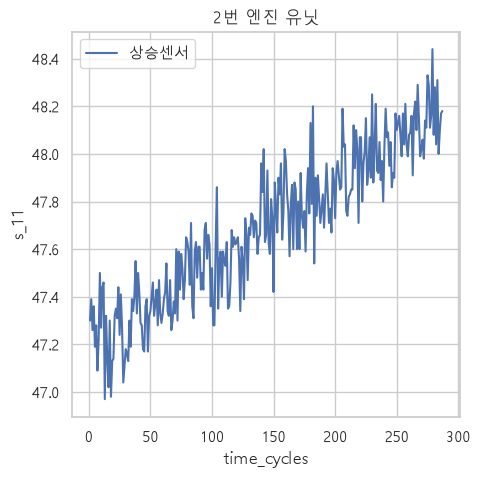

In [5]:
# 실습 6. 엔진 센서 시계열 그래프 그리기
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# x축(시간의 흐름) : time_cycles
plt.figure(figsize=(5, 5))
plt.title('2번 엔진 유닛')
plt.plot(engine2['time_cycles'], engine2['s_11'], label='상승센서')
# plt.plot(engine2['time_cycles'], engine2['s_7'], label='하강센서')
plt.xlabel('time_cycles')
plt.ylabel('s_11')
plt.legend()
plt.show()

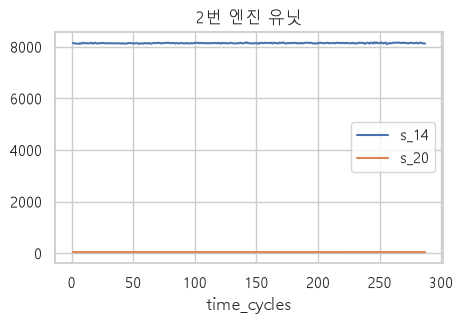

In [6]:
# 실습 7. 여러 센서 비교와 범위 문제
# s_2, s_7은 수치 범위가 수백 단위로 비슷하여 한 차트 안에서 둘 다 거동 파악이 가능합니다.
# 하지만 s_14(약 8천), s_20(약 30몇)처럼 스케일이 극도로 다른 두 센서를 한 도화지에 겹치면,
# y축 범위가 크게 벌어져 상대적으로 범위가 좁은 s_20은 완전히 수평선처럼 찌그러져 보이는 문제 발생
# 이런 스케일은 정규화전처리 또는 이중 y축(twinx)을 사용해야 합니다.
plt.figure(figsize=(5, 3))
plt.title('2번 엔진 유닛')
plt.plot(engine2['time_cycles'], engine2['s_14'], label='s_14')
plt.plot(engine2['time_cycles'], engine2['s_20'], label='s_20')
plt.xlabel('time_cycles')
plt.legend()
plt.show()

In [7]:
# 실습 8. 데이터 구조 미니 리포트
df = pd.read_csv('.venv/20_cmapss_fd001_sample.csv')

print(f'전체크기 : {df.shape}, 엔진대수 : {df['unit_nr'].nunique()}대')
print(f'데이터 유실 : {df.isna().sum().sum()}개')

target = 2
print(f'대상엔진 : {target}번')

engine = df[df['unit_nr'] == target]
print(f'엔진 {target}번 : {len(engine)}회차 기록됨, 결측 {engine.isna().sum().sum()}개')

for sensor in ['s_7', 's_11', 's_12']:
    start = engine2[sensor].iloc[0]
    end = engine2[sensor].iloc[-1]
    print(f'{sensor}의 데이터는 {start}로 시작해서 {end}로 끝납니다.')

# 전체크기 : (1116, 26), 엔진대수 : 5대
# 데이터 유실 : 0개
# 대상엔진 : 2번
# 엔진 2번 : 287회차 기록됨, 결측 0개
# s_7의 데이터는 553.84로 시작해서 546.17로 끝납니다.
# s_11의 데이터는 47.3로 시작해서 48.18로 끝납니다.
# s_12의 데이터는 520.52로 시작해서 513.55로 끝납니다.

    

전체크기 : (1116, 26), 엔진대수 : 5대
데이터 유실 : 0개
대상엔진 : 2번
엔진 2번 : 287회차 기록됨, 결측 0개
s_7의 데이터는 553.84로 시작해서 546.17로 끝납니다.
s_11의 데이터는 47.3로 시작해서 48.18로 끝납니다.
s_12의 데이터는 520.52로 시작해서 513.55로 끝납니다.
